<a href="https://colab.research.google.com/github/vananya19/fmml_aiml_lab_and_projects/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy.
import numpy as np
from numpy import linalg
from numpy.linalg import norm
from scipy.spatial.distance import squareform, pdist

# sklearn.
import sklearn
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale

# Random state.
RS = 2015010

# matplotlib.
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import matplotlib
%matplotlib inline

# seaborn.
import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('muted')
sns.set_context("notebook", font_scale=1.5,
                rc={"lines.linewidth": 3.5})

In [ ]:
digits = load_digits()
digits.data.shape

(1797, 64)

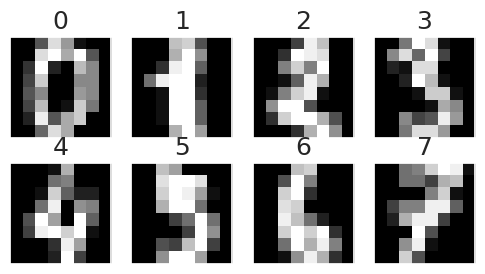

In [ ]:
nrows, ncols = 2, 4
plt.figure(figsize=(6,3))
plt.gray()
for i in range(ncols * nrows):
    ax = plt.subplot(nrows, ncols, i + 1)
    ax.matshow(digits.images[i,...])
    plt.xticks([]); plt.yticks([])
    plt.title(digits.target[i])

In [ ]:
# We first reorder the data points according to the handwritten numbers.
X = np.vstack([digits.data[digits.target==i]
               for i in range(10)])
y = np.hstack([digits.target[digits.target==i]
               for i in range(10)])

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS).fit_transform(X)

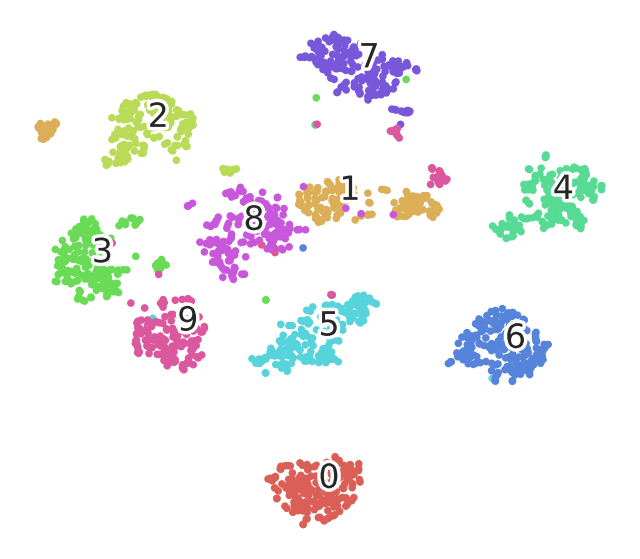

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x7808136fea50>)

In [ ]:
def scatter(x, colors):
    # We choose a color palette with seaborn.
    palette = np.array(sns.color_palette("hls", 10))

    # We create a scatter plot.
    f = plt.figure(figsize=(8, 7))
    ax = plt.subplot(aspect='equal')
    sc = ax.scatter(x[:,0], x[:,1], lw=0, s=30,
                    c=palette[colors.astype(int)])
    plt.xlim(-25, 25)
    plt.ylim(-25, 25)
    ax.axis('off')
    ax.axis('tight')

    # We add the labels for each digit.
    txts = []
    for i in range(10):
        # Position of each label.
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()])
        txts.append(txt)
    plt.show()

    return f, ax, sc

scatter(digits_proj, y)

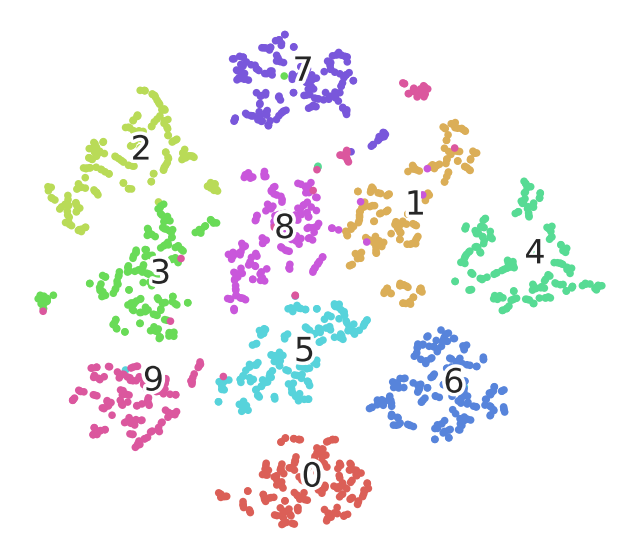

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x7808106ad340>)

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS, perplexity=5).fit_transform(X)

scatter(digits_proj, y)

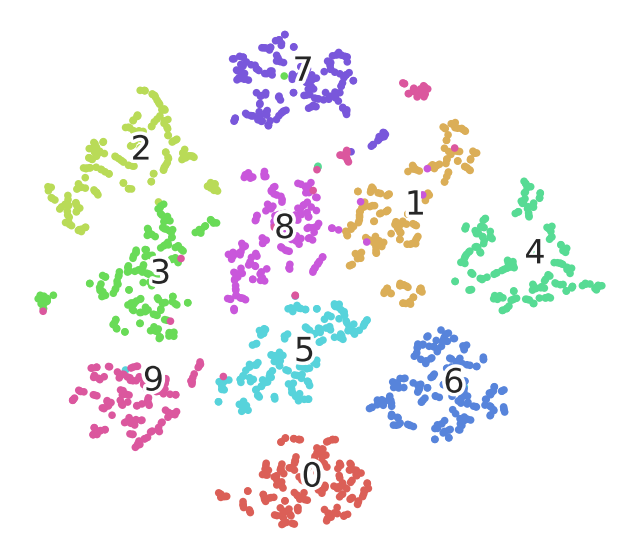

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x7808104fca40>)

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS, perplexity=5).fit_transform(X)

scatter(digits_proj, y)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


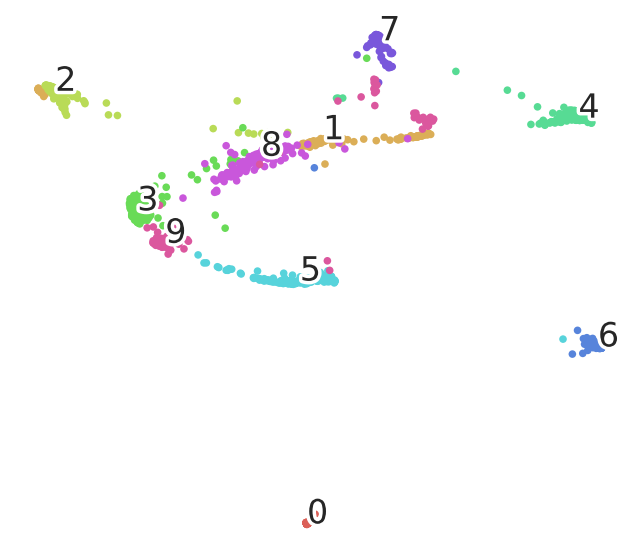

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x78081055c9e0>)

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS, n_iter=250).fit_transform(X)

scatter(digits_proj, y)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


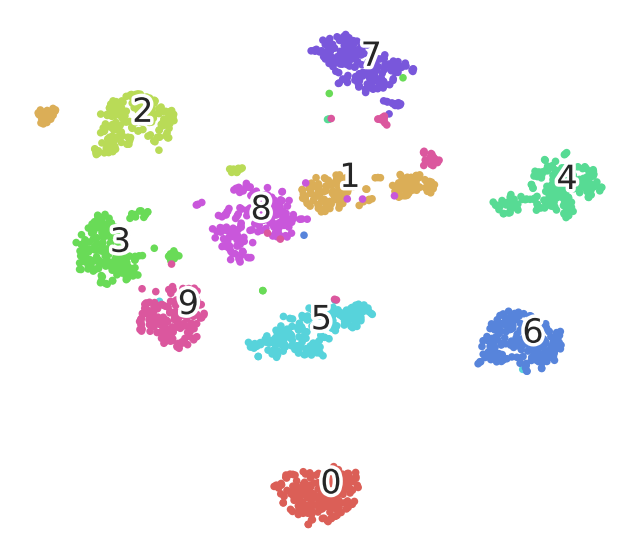

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x780813a056a0>)

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS, n_iter=5000).fit_transform(X)

scatter(digits_proj, y)

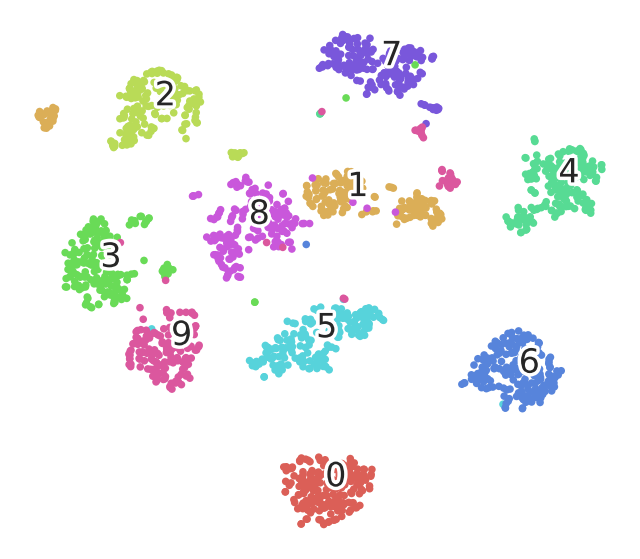

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x780810453dd0>)

In [ ]:
digits_proj = TSNE(init="pca", random_state=RS, method='exact').fit_transform(X)

scatter(digits_proj, y)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


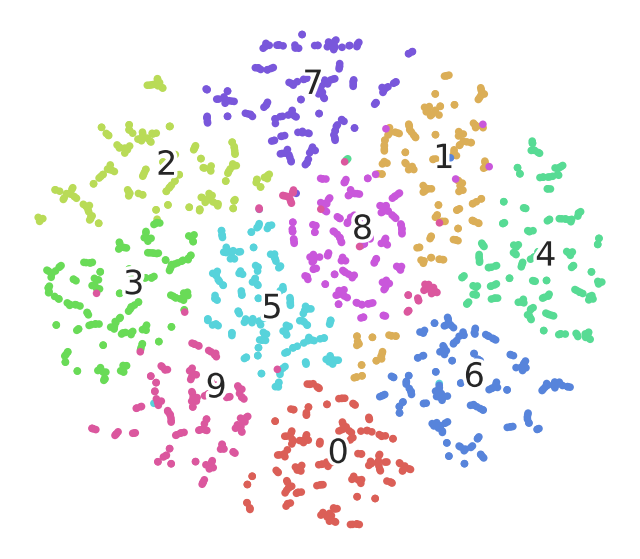

(<Figure size 800x700 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.PathCollection at 0x780810478620>)

In [ ]:
###############################################################
###### MODIFY THE VALUES FOR THE HYPERPARAMETERS BELOW ########

perplexity_value = 2
number_iterations = 1000
method = "barnes_hut"

###############################################################

digits_proj = TSNE(init="pca", random_state=RS, n_iter=number_iterations, perplexity=perplexity_value, method=method).fit_transform(X)
scatter(digits_proj, y)

In [ ]:
# **PCA vs t-SNE — Key Differences

### **a. Linearity**

* **PCA → Linear** (straight-line transformation).
* **t-SNE → Non-linear** (captures curved/complex structures).

### **b. Why non-linearity helps**

* t-SNE can **separate clusters that are non-linearly arranged**, uncovering structure PCA cannot show.

### **c. What structure they preserve**

* **PCA → Preserves global structure** (far points remain far).
* **t-SNE → Preserves local neighbourhoods** (similar points stay close), global distances **not reliable**.

### **d. Computational cost**

* **PCA → Fast** (uses SVD; scalable).
* **t-SNE → Slow & expensive**

  * Classic: **O(n²)**
  * Barnes–Hut: **O(n log n)**

---

# **t-SNE Computational Complexity

* **Scales poorly with dataset size n** (pairwise comparisons → O(n²) time & memory).
* High dimensionality **increases distance computation cost**, so PCA (→ 30–50 dims) is often done before t-SNE.
* Runtime grows with **iterations**, **perplexity**, and n.

---

# **t-SNE Limitations / Pitfalls

1. **Does NOT preserve global structure** → distances between clusters are not meaningful.
2. **Sensitive to hyperparameters** (perplexity, learning rate) → results change easily.
3. **Computationally expensive** → slow for datasets >10k without approximations.
4. **Can create misleading clusters** → users may over-interpret the plot.

---


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


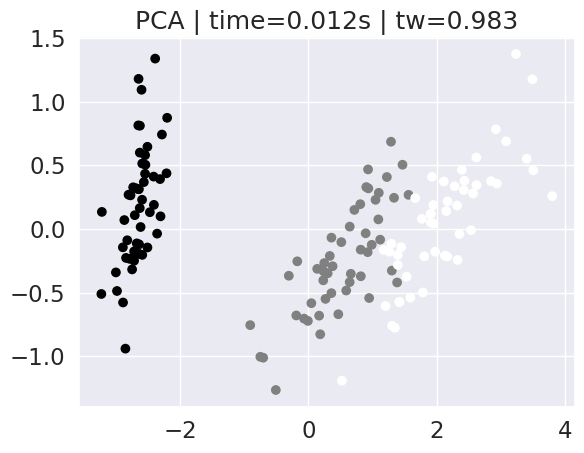

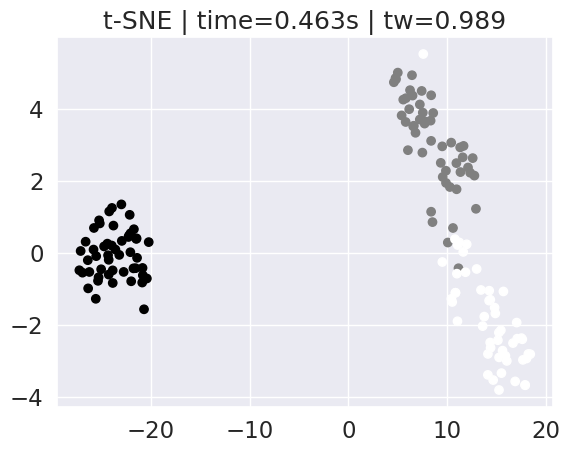

  method  runtime(s)  trustworthiness
0    PCA    0.012136         0.982944
1  t-SNE    0.462848         0.988535


In [ ]:
# PCA vs t-SNE Quick Demo (Iris dataset)
import time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

# Load data
X, y = datasets.load_iris(return_X_y=True)

# PCA
t0 = time.time()
X_pca = PCA(n_components=2).fit_transform(X)
pca_time = time.time() - t0

# t-SNE
t1 = time.time()
X_tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, init='pca').fit_transform(X)
tsne_time = time.time() - t1

# Trustworthiness
tw_pca = trustworthiness(X, X_pca, n_neighbors=10)
tw_tsne = trustworthiness(X, X_tsne, n_neighbors=10)

# Plot PCA
plt.figure(); plt.scatter(X_pca[:,0], X_pca[:,1], c=y);
plt.title(f"PCA | time={pca_time:.3f}s | tw={tw_pca:.3f}"); plt.show()

# Plot t-SNE
plt.figure(); plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y);
plt.title(f"t-SNE | time={tsne_time:.3f}s | tw={tw_tsne:.3f}"); plt.show()

# Summary
print(pd.DataFrame({
    "method":["PCA","t-SNE"],
    "runtime(s)":[pca_time, tsne_time],
    "trustworthiness":[tw_pca, tw_tsne]
}))